# Spam Detection: Naive Bayes vs SVM

**Student Name:** ___Logan Douglas______  
**Date:** _____02/20/2026__

In this project, you'll:
1. Load a spam email dataset
2. Train a Naive Bayes classifier
3. Train an SVM classifier
4. Compare the results

<small><i>Note</i>: This project was created with the assistance of AI</small>

---

## Step 1: Import Libraries and Load Data

In [23]:
# Import libraries
import pandas as pd
import numpy as np
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Load the dataset
df = pd.read_csv('../data/spam_data.csv')

# Display first few rows
df.head()

,word_free,word_money,word_winner,word_click,word_urgent,num_exclamation,num_dollar,num_capitals,email_length,has_link,is_spam
0,0.116603,0.081405,0.248621,0.107026,0.084280,0.162809,0.042277,0.240659,101.836546,0.296066,0
1,0.150017,0.202468,0.071720,0.227412,0.228002,0.093779,0.123205,0.062907,90.571442,0.193681,0
2,0.009429,0.190923,0.094307,0.152571,0.272270,0.074788,0.123115,0.226665,130.369345,0.023094,0
3,0.085727,0.129830,0.205633,0.099737,0.016976,0.112176,0.283335,0.192520,98.526674,0.189685,0
4,0.050113,0.050286,0.011001,0.220921,0.199141,0.142389,0.253251,0.241701,96.637459,0.260481,0


## Step 2: Preprocessing the Data
* Clean the data
* Split the data into training and test sets.
* Feature Scaling

In [4]:
# Check for missing data
print(df.isnull().sum())

# Drop any rows with missing values (if any)
df_clean = df.dropna()



word_free          0
word_money         0
word_winner        0
word_click         0
word_urgent        0
num_exclamation    0
num_dollar         0
num_capitals       0
email_length       0
has_link           0
is_spam            0
dtype: int64


In [5]:
# Split the data using a random state of 42 for reproducibility

X = df_clean.drop('is_spam', axis=1)
y = df_clean['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 3: Train Naive Bayes Classifier

In [6]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


In [7]:
y_pred_nb = nb_model.predict(X_test_scaled)

Display your confusion matrix and your classification report.

In [8]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)

[[113   0]
 [  0  87]]


## Step 4: Train k-Nearest Neighbors Classifier

In [17]:
k = int(sqrt(len(df)))
print(k)

# Retrain with best k
knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X_train_scaled, y_train)

31


,n_neighbors,31
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:

y_pred_knn = knn_model.predict(X_test_scaled)

Display your confusion matrix and classification report.

In [19]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

[[113   0]
 [  0  87]]


## Step 5: Train SVM Classifier

In [20]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
y_pred_svm = svm_model.predict(X_test_scaled)

Display your confusion matrix and your classification report.

In [22]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

[[113   0]
 [  0  87]]


## Step 6: Compare the Models
* Create graphs that compare model results
* Make calculations to compare model results

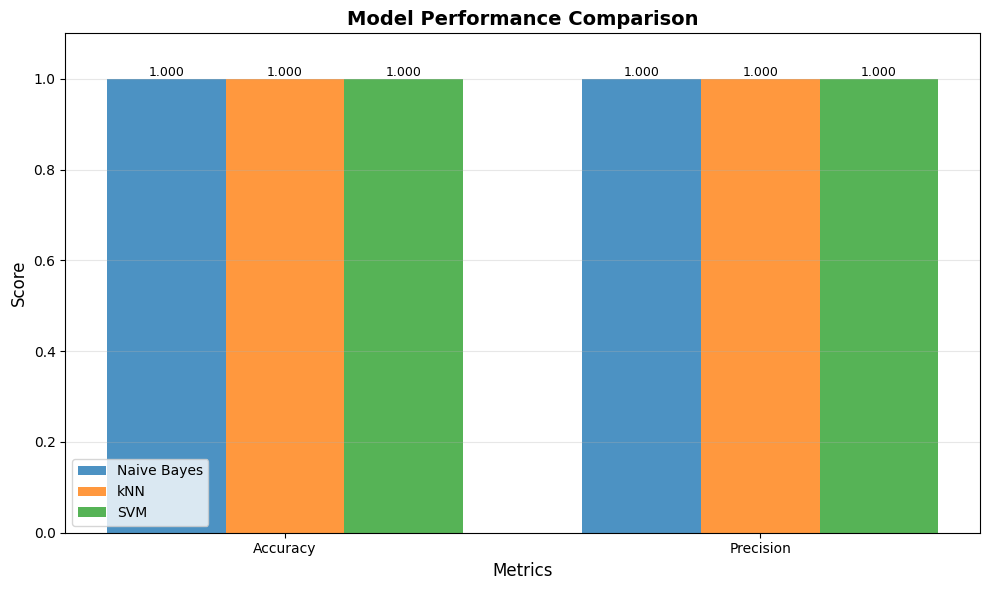

In [ ]:

def calculate_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    return accuracy, precision

nb_acc, nb_prec = calculate_metrics(cm_nb)
knn_acc, knn_prec = calculate_metrics(cm_knn)
svm_acc, svm_prec = calculate_metrics(cm_svm)

metrics_names = ['Accuracy', 'Precision']
x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, [nb_acc, nb_prec], width, label='Naive Bayes', alpha=0.8)
bars2 = ax.bar(x, [knn_acc, knn_prec], width, label='kNN', alpha=0.8)
bars3 = ax.bar(x + width, [svm_acc, svm_prec], width, label='SVM', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
def calculate_all_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1_score

# Calculate metrics for all models
nb_metrics = calculate_all_metrics(cm_nb)
knn_metrics = calculate_all_metrics(cm_knn)
svm_metrics = calculate_all_metrics(cm_svm)

# Print comparison table
print("MODEL PERFORMANCE COMPARISON")
print(f"{'Metric':<15} {'Naive Bayes':<15} {'kNN':<15} {'SVM':<15}")
print(f"{'Accuracy':<15} {nb_metrics[0]:<15.4f} {knn_metrics[0]:<15.4f} {svm_metrics[0]:<15.4f}")
print(f"{'Precision':<15} {nb_metrics[1]:<15.4f} {knn_metrics[1]:<15.4f} {svm_metrics[1]:<15.4f}")
print(f"{'Recall':<15} {nb_metrics[2]:<15.4f} {knn_metrics[2]:<15.4f} {svm_metrics[2]:<15.4f}")
print(f"{'F1-Score':<15} {nb_metrics[3]:<15.4f} {knn_metrics[3]:<15.4f} {svm_metrics[3]:<15.4f}")

MODEL PERFORMANCE COMPARISON
Metric          Naive Bayes     kNN             SVM            
Accuracy        1.0000          1.0000          1.0000         
Precision       1.0000          1.0000          1.0000         
Recall          1.0000          1.0000          1.0000         
F1-Score        1.0000          1.0000          1.0000         


Discuss the results of your comparison.

## Step 7: Answer Discussion Questions

Based on your results, answer the following questions:

### Question 1: Which model performed better overall? Why do you think so?

**Your Answer:**

_Every model got a perfect score. I think that this happened because all of the data being generated by AI caused it to be easily seperated. This is most likely why all performed equally._

---

### Question 2: What is the difference between accuracy and precision? Which is more important for spam detection?

**Your Answer:**

_Accuracy is how often a classification is overall while percision is for how often a model is correct when predicting a certain class. For spam detection I believe that percision is more important as you are trying to preict how often the target class is being predicted correctly._

---

### Question 3: When would you choose Naive Bayes over kNN or SVM in a real-world application?

**Your Answer:**

_The best time to choose Naive Bayes over kNN or SVM is when you need something quick and an estimate would be ok. Otherwise a good time to choose it over the other two would be if all varaibles are independent from each other._

---

### Question 4: What are the key assumptions of Naive Bayes? Do you think they hold true for this spam detection problem?

**Your Answer:**

_Naive Bayes assumes that all variables are independent from each other. In this case the variables for spam detection would be dependent such as the words click and free appearing more often together._

---

### Question 5: How did you determine your value for $k$ in the kNN model?

**Your Answer:**

_I did this simply by just taking the square root of the number entries to get the k value._

---

## Summary

In this project, you:
- ✅ Loaded and split a spam detection dataset
- ✅ Trained a Naive Bayes classifier
- ✅ Trained an SVM classifier  
- ✅ Compared both models using multiple metrics
- ✅ Analyzed the results

**Key Takeaways:**
1. Different algorithms can produce different results on the same data
2. Multiple metrics (accuracy, precision, recall) give a complete picture
3. Both Naive Bayes and SVM are effective for classification tasks
4. The choice of algorithm depends on the specific requirements of your problem